# Machine Learning II - Project 3
## CIFAR 100 Model Building, Tuning, and Analysis
### Gwen Horzempa

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data.sampler import SubsetRandomSampler
import torch.optim
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

import torchvision as tv
from torchvision import datasets
import torchvision.transforms as T
import torchvision.models
import torch.optim as optim
import optuna
from optuna.integration import PyTorchLightningPruningCallback

import random
import multiprocessing
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

For the next block, I got the values here:
https://gist.github.com/weiaicunzai/e623931921efefd4c331622c344d8151

## Data Transformations

In [2]:
def get_transforms(rand_augment_magnitude):

    # These are the per-channel mean and std of CIFAR-100 over the dataset
    mean = (0.5071, 0.4867, 0.4408)
    std = (0.2470, 0.2435, 0.2616)

    # Define our transformations
    return {"train": T.Compose([
                T.Resize(256), # All images in CIFAR-10 are 32x32. We enlarge them a bit so we can then take a random crop
                T.RandomCrop(224), # take a random part of the image
                T.RandomHorizontalFlip(0.5),
                T.RandAugment(num_ops=2, magnitude=rand_augment_magnitude, interpolation=T.InterpolationMode.BILINEAR,),
                T.ToTensor(),
                T.Normalize(mean, std),]),
            "valid": T.Compose([
                T.Resize(256),
                T.CenterCrop(224),
                T.ToTensor(),
                T.Normalize(mean, std),]),
            "test": T.Compose([
                T.Resize(256),
                T.CenterCrop(224),
                T.ToTensor(),
                T.Normalize(mean, std),]),}

In [3]:
def get_data_loaders(batch_size, valid_size, transforms, num_workers, random_seed=1971):

    # Reseed random number generators to get a deterministic split. This is useful when comparing experiments, so you'll know they all run on the same data.
    # In principle you should repeat this a few times (cross validation) to see the variability of your measurements.
    torch.manual_seed(random_seed)
    random.seed(random_seed)
    np.random.seed(random_seed)

    # Get the CIFAR100 training dataset from torchvision.datasets and set the transforms.
    # We will split this further into train and validation in this function.
    train_data = datasets.CIFAR100("data", train=True, download=True, transform=transforms['train'])
    valid_data = datasets.CIFAR100("data", train=True, download=True, transform=transforms['valid'])

    # Compute how many items we will reserve for the validation set
    n_tot = len(train_data)
    split = int(np.floor(valid_size * n_tot))

    # compute the indices for the training set and for the validation set
    shuffled_indices = torch.randperm(n_tot)
    train_idx, valid_idx = shuffled_indices[split:], shuffled_indices[:split]

    # define samplers for obtaining training and validation batches
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    # prepare data loaders (combine dataset and sampler)
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
    valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)

    # Get the CIFAR100 test dataset from torchvision.datasets, set the transforms, and prepare the data loader.

    test_data = datasets.CIFAR100("data", train=False, download=True, transform=transforms['test'])
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

    return {'train': train_loader, 'valid': valid_loader, 'test': test_loader}

In [4]:
# n_workers = multiprocessing.cpu_count() # number of logical CPUs
# print('Using {} logical CPUs.'.format(n_workers))

n_workers = 2
batch_size = 32 # training batch size
valid_size = 0.2 # proportion of downloaded training data to use for validation

transforms = get_transforms(rand_augment_magnitude=9)
data_loaders = get_data_loaders(batch_size, valid_size, transforms, n_workers)

/home/gw3n/.conda/envs/py314_pt210/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
classes = data_loaders['train'].dataset.classes
print(classes)
n_classes = len(classes)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

## Hyperparameter Tuning

In [ ]:
class Net(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.model = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
        )

        n_inputs = self.model.fc.in_features

        layers = []
        in_features = n_inputs

        layers.append(nn.Linear(in_features, n_classes))

        self.model.fc = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
class Net(nn.Module):
    def __init__(self, n_classes, n_layers, hidden_size):
        super().__init__()
        self.model = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
        )

        n_inputs = self.model.fc.in_features

        layers = []
        in_features = n_inputs

        for i in range(n_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size

        layers.append(nn.Linear(in_features, n_classes))

        self.model.fc = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
class Net(nn.Module):
    def __init__(self, n_classes, hidden_size1, hidden_size2, dropout1):
        super().__init__()
        self.model = torchvision.models.resnet50(
                weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
            )

        n_inputs = self.model.fc.in_features
    
        self.model.fc = nn.Sequential(
            nn.Linear(n_inputs, hidden_size1),
            nn.BatchNorm1d(hidden_size1),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(hidden_size1, hidden_size2),
            nn.BatchNorm1d(hidden_size2),
            nn.ReLU(),
            nn.Linear(hidden_size2, n_classes),
        )
       
    def forward(self, x):
        return self.model(x)


In [ ]:


def objective(trial, transforms=transforms, n_workers=2, n_classes=n_classes, data_loaders=data_loaders):
    hidden_size1 = trial.suggest_int("hidden_size1", 128, 512)
    hidden_size2 = trial.suggest_int("hidden_size2", 64, 256)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    dropout1 = trial.suggest_float("dropout1", 0.2, 0.5)
    
    train_loader = data_loaders["train"]
    valid_dataloader = data_loaders["valid"]

    model = Net(n_classes, hidden_size1, hidden_size2, dropout1)
    if torch.cuda.is_available():
        model.cuda()

    for p in model.parameters():
        # Freeze only parameters that are not already frozen
        if p.requires_grad:
            p.requires_grad = False
    
    # Now let's thaw the parameters of the head we have added
    for p in model.model.fc.parameters():
        p.requires_grad = True

    
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )
    loss = nn.CrossEntropyLoss()
    print("Optimizer and loss set")

    model.train()
    for epoch in range(5):
        print("We're in...")
        for batch_idx, (data, target) in tqdm(enumerate(train_loader)):
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()
            optimizer.zero_grad()
            output = model(data)
            train_loss = loss(output, target)
            train_loss.backward()
            optimizer.step()
        print(f"Training {batch_idx} Done")

        val_loss = 0.0

        with torch.no_grad():
            model.eval()

            for batch_idx, (data, target) in tqdm(
                enumerate(valid_dataloader)):
                # move data to GPU if available
                if torch.cuda.is_available():
                    data, target = data.cuda(), target.cuda()
    
                output = model(data)
                val_loss += loss(output, target).item()
            val_loss /= len(valid_dataloader)
            print(f"Validating {batch_idx} Done")
    del model
    torch.cuda.empty_cache()

    return val_loss



In [ ]:

torch.cuda.empty_cache()
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)
print("Best Hyperparameters:", study.best_params)

# Model Building

In [ ]:
# After hyperparameter tuning round 1:
hidden_size = 170
learning_rate = 0.0013095215918183867

In [ ]:
# After hyperparameter tuning round 2:
hidden_size = 464
learning_rate = 0.00262044778178876
dropout_rate = 0.2326505128243023
batch_size = 32

In [ ]:
# After hyperparameter tuning round 3:
hidden_size = 206
learning_rate = 0.002193451411259431
n_layers = 1

In [6]:
# After hyperparameter tuning round 4:
hidden_size1 = 372
hidden_size2 = 199
learning_rate = 0.0001081153035018974
dropout1 = 0.38573786144706623

In [ ]:
learning_rate = 0.002

In [ ]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)

n_classes = len(classes)
n_inputs = model.fc.in_features

# Feel free to experiment with more complicated heads

model.fc = nn.Sequential(nn.Linear(n_inputs, hidden_size),
                         nn.BatchNorm1d(hidden_size),
                         nn.ReLU(),
                         nn.Linear(hidden_size, n_classes))

In [ ]:

model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)

n_classes = len(classes)
n_inputs = model.fc.in_features

# Feel free to experiment with more complicated heads

model.fc = nn.Sequential(nn.Linear(n_inputs, hidden_size),
                         nn.ReLU(),
                         nn.Dropout(p=dropout_rate),
                         nn.Linear(hidden_size, hidden_size),
                         nn.ReLU(),
                         nn.Dropout(p=dropout_rate),
                         nn.Linear(hidden_size, n_classes))

In [7]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)

n_inputs = model.fc.in_features
    
model.fc = nn.Sequential(
    nn.Linear(n_inputs, hidden_size1),
    nn.BatchNorm1d(hidden_size1),
    nn.ReLU(),
    nn.Dropout(dropout1),
    nn.Linear(hidden_size1, hidden_size2),
    nn.BatchNorm1d(hidden_size2),
    nn.ReLU(),
    nn.Linear(hidden_size2, n_classes),
)

### Adjusting the Trainability of Parameters
- Now we want to make it so that the parameters of the model's backbone are not trainable; this is called freezing the backbone
- We also want to ensure that the fully connected layer that we just added has trainable parameters; this is called thawing the head

In [8]:
frozen_parameters = []

for p in model.parameters():
    # Freeze only parameters that are not already frozen
    if p.requires_grad:
        p.requires_grad = False
        frozen_parameters.append(p)

print(f"Froze {len(frozen_parameters)} groups of parameters")

# Now let's thaw the parameters of the head we have added
for p in model.fc.parameters():
    p.requires_grad = True

Froze 169 groups of parameters


In [9]:
# Print the model if you want to see what it looks like.
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Run this cell to see how many trainable parameters there are.

sum(p.numel() for p in model.parameters() if p.requires_grad)

### Define Loss Function and Optimizer

In [10]:
# specify loss function (categorical cross-entropy)
loss = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

## Train the Model

In [11]:
def train_one_epoch(train_dataloader, model, optimizer, loss):
    """
    Performs one epoch of training
    """

    # Move model to GPU if available
    if torch.cuda.is_available():
        model.cuda()  # -

    # Set the model to training mode. Some layers perform differently depending
    # on whether or not you are training or evaluating, e.g., batch normalization
    # and dropout.
    model.train()

    # Loop over the training data
    train_loss = 0.0

    for batch_idx, (data, target) in tqdm(
        enumerate(train_dataloader),
        desc="Training",
        total=len(train_dataloader),
        leave=True,
        ncols=80,
    ):
        # move data to GPU if available
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        # 1. clear the gradients of all optimized variables
        optimizer.zero_grad()

        # 2. forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)

        # 3. calculate the loss
        loss_value = loss(output, target)

        # 4. backward pass: compute gradient of the loss with respect to model parameters
        loss_value.backward() # The .backward() method is built-in; we don't have to define it in our model.

        # 5. perform a single optimization step (parameter update)
        optimizer.step()

        # update average training loss
        train_loss = train_loss + (
            (1 / (batch_idx + 1)) * (loss_value.data.item() - train_loss))

    return train_loss

In [12]:
def valid_one_epoch(valid_dataloader, model, loss):
    """
    Validate at the end of one epoch
    """

    # During validation we don't need to accumulate gradients
    with torch.no_grad():

        # Set the model to evaluation mode. Some layers perform differently depending
        # on whether or not you are training or evaluating, e.g., batch normalization
        # and dropout.
        model.eval()

        # If the GPU is available, move the model to the GPU
        if torch.cuda.is_available():
            model.cuda()

        # Loop over the validation dataset and accumulate the loss
        valid_loss = 0.0
        for batch_idx, (data, target) in tqdm(
            enumerate(valid_dataloader),
            desc="Validating",
            total=len(valid_dataloader),
            leave=True,
            ncols=80,
        ):
            # move data to GPU if available
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            # 1. forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)

            # 2. calculate the loss
            loss_value = loss(output, target)

            # Calculate average validation loss
            valid_loss = valid_loss + (
                (1 / (batch_idx + 1)) * (loss_value.data.item() - valid_loss))

    return valid_loss

In [13]:
def optimize(data_loaders, model, optimizer, loss, n_epochs, save_path, patience, scheduler, interactive_tracking=False):
    # initialize tracker for minimum validation loss
    if interactive_tracking:
        liveloss = PlotLosses()
    else:
        liveloss = None

    # Loop over the epochs and keep track of the minimum of the validation loss
    valid_loss_min = None
    logs = {}
    wait = 0

    for epoch in range(1, n_epochs + 1):

        train_loss = train_one_epoch(
            data_loaders["train"], model, optimizer, loss
        )

        valid_loss = valid_one_epoch(data_loaders["valid"], model, loss)

        # print training/validation statistics
        print(f"Epoch: {epoch} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {valid_loss:.6f}")

        # If the validation loss decreases by more than 1%, save the model
        if valid_loss_min is None or ((valid_loss_min - valid_loss) / valid_loss_min > 0.01):
            print(f"New minimum validation loss: {valid_loss:.6f}. Saving model ...")

            # Save the weights to save_path
            torch.save(model.state_dict(), save_path)  # -

            valid_loss_min = valid_loss
            wait = 0
        else:
            wait +=1
            if wait >= patience:
                print("Early stopping!")
                break
            

        # Update learning rate, i.e., make a step in the learning rate scheduler
        scheduler.step(valid_loss)

        # Log the losses and the current learning rate
        if interactive_tracking:
            logs["loss"] = train_loss
            logs["val_loss"] = valid_loss
            logs["lr"] = optimizer.param_groups[0]["lr"]
            liveloss.update(logs)
            liveloss.send()

### Training the Head

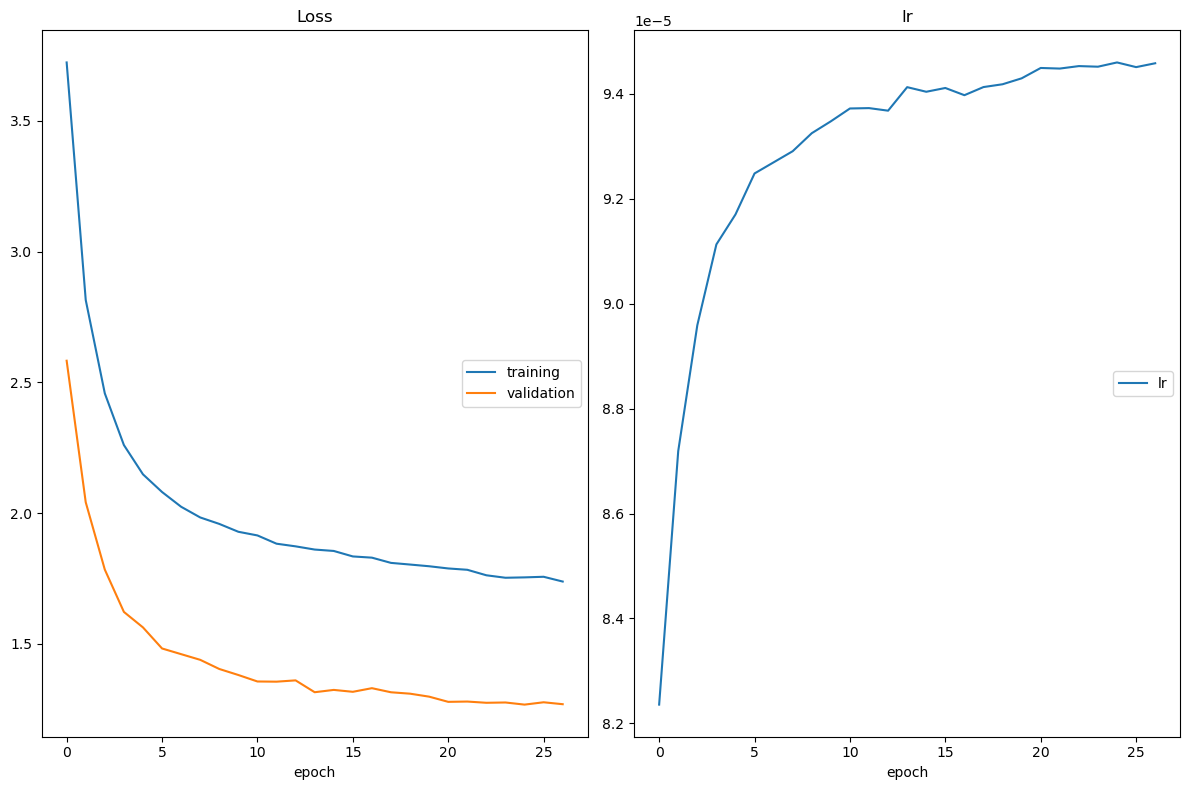

Loss
	training         	 (min:    1.738, max:    3.724, cur:    1.738)
	validation       	 (min:    1.268, max:    2.583, cur:    1.269)
lr
	lr               	 (min:    0.000, max:    0.000, cur:    0.000)


Validating: 100%|█████████████████████████████| 313/313 [01:01<00:00,  5.10it/s]

Epoch: 28 	Training Loss: 1.746433 	Validation Loss: 1.282288
Early stopping!


In [14]:

n_epochs = 100

optimize(
    data_loaders,
    model,
    optimizer,
    loss,
    n_epochs,
    'trial4.pt',
    7,
    scheduler,
    interactive_tracking=True
)

## Evaluating the Model

In [15]:
def one_epoch_test(test_dataloader, model, loss):
    # monitor test loss and accuracy
    test_loss = 0.
    correct = 0.
    total = 0.

    # we do not need the gradients
    with torch.no_grad():

        # set the model to evaluation mode
        model.eval()  # -

        # if the GPU is available, move the model to the GPU
        if torch.cuda.is_available():
            model = model.cuda()

        # Loop over test dataset
        # We also accumulate predictions and targets so we can return them
        preds = []
        actuals = []

        for batch_idx, (data, target) in tqdm(
                enumerate(test_dataloader),
                desc='Testing',
                total=len(test_dataloader),
                leave=True,
                ncols=80
        ):
            # move data to GPU if available
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            # 1. forward pass: compute predicted outputs by passing inputs to the model
            logits = model(data)  # =

            # 2. calculate the loss
            loss_value = loss(logits, target).detach()  # =

            # 3. update average test loss
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss_value.data.item() - test_loss))

            # 4. convert logits to predicted class
            # NOTE: the predicted class is the index of the max of the logits
            pred = logits.data.max(1, keepdim=True)[1]  # =

            # 5. compare predictions to true label
            correct += torch.sum(torch.squeeze(pred.eq(target.data.view_as(pred))).cpu())
            total += data.size(0)

            preds.extend(pred.data.cpu().numpy().squeeze())
            actuals.extend(target.data.view_as(pred).cpu().numpy().squeeze())

    print('Test Loss: {:.6f}\n'.format(test_loss))

    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (100. * correct / total, correct, total))

    return test_loss, preds, actuals

In [16]:
model.load_state_dict(torch.load('trial4.pt'))

<All keys matched successfully>

In [17]:
test_loss, preds, actuals = one_epoch_test(data_loaders['test'], model, loss)

Testing: 100%|████████████████████████████████| 313/313 [01:01<00:00,  5.06it/s]

Test Loss: 1.274914


Test Accuracy: 63% (6371/10000)


In [ ]:
def plot_confusion_matrix(pred, truth, classes):

    gt = pd.Series(truth, name='Ground Truth')
    predicted = pd.Series(pred, name='Predicted')

    confusion_matrix = pd.crosstab(gt, predicted)
    confusion_matrix.index = classes
    confusion_matrix.columns = classes

    fig, sub = plt.subplots()
    with sns.plotting_context("notebook"):

        ax = sns.heatmap(
            confusion_matrix,
            annot=True,
            fmt='d',
            ax=sub,
            linewidths=0.5,
            linecolor='lightgray',
            cbar=False
        )
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")

    return confusion_matrix

In [ ]:
cm = plot_confusion_matrix(preds, actuals, classes)

In [ ]:
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img, sub):
    img = img / 2 + 0.5  # unnormalize
    sub.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image
    sub.axis("off")

In [ ]:
# obtain one batch of test images
dataiter = iter(data_loaders['test'])

for i in range(2):
    images, labels = next(dataiter)
    images.numpy()

    # move model inputs to cuda, if GPU available
    if train_on_gpu:
        images = images.cuda()

    # get sample outputs
    output = model(images)
    # convert output probabilities to predicted class
    _, preds_tensor = torch.max(output, 1)
    preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

    # plot the images in the batch, along with predicted and true labels
    fig, subs = plt.subplots(2, 10, figsize=(25, 4))
    for i, ax in enumerate(subs.flatten()):
        imshow(images[i].cpu().numpy(), ax)
        ax.set_title("{} ({})".format(classes[preds[i]], classes[labels[i]]),
                     color=("green" if preds[i]==labels[i].item() else "red"))
        ax.axis("off")